In [31]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
stock_name ="RELIANCE.NS"
start_date ="2021-01-01"
end_date = "2026-01-01"

In [3]:
data =yf.download(stock_name,start=start_date,end=end_date)

# If 'yfinance' gives a double-layered table, we strip out the ticker names
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

data.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-24,1551.028687,1568.448147,1546.449881,1565.461954,8815745
2025-12-26,1552.024048,1553.815812,1547.146696,1547.544758,2311495
2025-12-29,1538.486694,1550.929166,1536.495899,1547.743942,5972105
2025-12-30,1532.713379,1546.449794,1530.722584,1539.880194,8815884
2025-12-31,1563.172607,1569.742208,1533.907890,1533.907890,5771830


In [4]:
price_diff = data["Close"].diff()

In [5]:
gains = price_diff.where(price_diff>0,0)
losses = -price_diff.where(price_diff<0,0)

In [6]:
avg_gain = gains.rolling(window=14).mean()
avg_loss = losses.rolling(14).mean()

In [7]:
rs = avg_gain / (avg_loss + 1e-8) 
data["RSI"] = 100- (100/(1+rs))

In [8]:
volume_20_ma = data["Volume"].rolling(20).mean()
data["Volume_Ratio"] = data["Volume"]/( volume_20_ma+ 1e-8)

In [9]:
data.head()

Price,Close,High,Low,Open,Volume,RSI,Volume_Ratio
Date,,,,,,,
2021-01-01,897.047058,901.334799,894.564644,897.272694,10015175,NaN,NaN
2021-01-04,898.559082,902.192359,888.245845,900.477287,24513534,NaN,NaN
2021-01-05,887.388245,895.286758,882.829622,888.697112,24123091,NaN,NaN
2021-01-06,863.986084,887.343111,859.878852,887.297984,46401468,NaN,NaN
2021-01-07,862.586914,877.864919,859.878864,866.806964,32325918,NaN,NaN


In [10]:
data = data.dropna()

In [11]:
data.head()

Price,Close,High,Low,Open,Volume,RSI,Volume_Ratio
Date,,,,,,,
2021-01-29,831.353882,863.467019,825.960286,854.981732,43712383,42.074810,1.344657
2021-02-01,855.433167,859.811162,834.084537,839.229874,34180952,49.836351,1.013775
2021-02-02,869.199158,875.608235,837.221402,863.986130,41470034,47.241598,1.199793
2021-02-03,871.388184,881.024334,857.554428,870.327515,30301696,49.263188,0.868909
2021-02-04,868.522095,875.608199,859.811112,868.386653,25626981,46.623889,0.757421


### Downloading Data for Nifty 200 ( using yfinance ) for last 3 years 

In [12]:
tickers = [
    "ABB.NS", "ACC.NS", "AUBANK.NS", "ABBOTINDIA.NS", "ADANIENSOL.NS", "ADANIENT.NS", "ADANIGREEN.NS",
    "ADANIPORTS.NS", "ADANIPOWER.NS", "ATGL.NS", "AWL.NS", "ABCAPITAL.NS", "ABFRL.NS", "ALKEM.NS",
    "AMBUJACEM.NS", "APOLLOHOSP.NS", "APOLLOTYRE.NS", "ASHOKLEY.NS", "ASIANPAINT.NS", "ASTRAL.NS",
    "AUROPHARMA.NS", "DMART.NS", "AXISBANK.NS", "BSE.NS", "BAJAJ-AUTO.NS", "BAJFINANCE.NS",
    "BAJAJFINSV.NS", "BAJAJHLDNG.NS", "BALKRISIND.NS", "BANDHANBNK.NS", "BANKBARODA.NS", "BANKINDIA.NS",
    "MAHABANK.NS", "BATAINDIA.NS", "BERGEPAINT.NS", "BEL.NS", "BHARATFORG.NS", "BHEL.NS", "BPCL.NS",
    "BHARTIARTL.NS", "BIOCON.NS", "BOSCHLTD.NS", "BRITANNIA.NS", "CGPOWER.NS", "CANBK.NS",
    "CHOLAFIN.NS", "CIPLA.NS", "COALINDIA.NS", "COFORGE.NS", "COLPAL.NS", "CONCOR.NS", "COROMANDEL.NS",
    "CROMPTON.NS", "CUMMINSIND.NS", "DLF.NS", "DABUR.NS", "DALBHARAT.NS", "DEEPAKNTR.NS",
    "DELHIVERY.NS", "DIVISLAB.NS", "DIXON.NS", "LALPATHLAB.NS", "DRREDDY.NS", "EICHERMOT.NS",
    "ESCORTS.NS", "NYKAA.NS", "FEDERALBNK.NS", "FACT.NS", "FORTIS.NS", "GAIL.NS", "GMRINFRA.NS",
    "GLAND.NS", "GLENMARK.NS", "GODREJCP.NS", "GODREJPROP.NS", "GRASIM.NS", "GUJGASLTD.NS",
    "HCLTECH.NS", "HDFCAMC.NS", "HDFCBANK.NS", "HDFCLIFE.NS", "HAVELLS.NS", "HEROMOTOCO.NS",
    "HINDALCO.NS", "HAL.NS", "HINDCOPPER.NS", "HINDPETRO.NS", "HINDUNILVR.NS", "ICICIBANK.NS",
    "ICICIGI.NS", "ICICIPRULI.NS", "IDBI.NS", "IDFCFIRSTB.NS", "ITC.NS", "INDIANB.NS", "IEX.NS",
    "INDHOTEL.NS", "IOC.NS", "IRCTC.NS", "IRFC.NS", "INDIGOPNTS.NS", "IGL.NS", "INDUSTOWER.NS",
    "INDUSINDBK.NS", "NAUKRI.NS", "INFY.NS", "INDIGO.NS", "IPCALAB.NS", "JINDALSTEL.NS", "JIOFIN.NS",
    "JSWENERGY.NS", "JSWSTEEL.NS", "JUBLFOOD.NS", "KALYANKJIL.NS", "KOTAKBANK.NS", "KPITTECH.NS",
    "L&TFH.NS", "LTTS.NS", "LICHSGFIN.NS", "LTI.NS", "LT.NS", "LAURUSLABS.NS", "LICI.NS", "LUPIN.NS",
    "MRF.NS", "LODHA.NS", "M&MFIN.NS", "M&M.NS", "MANAPPURAM.NS", "MARICO.NS", "MARUTI.NS",
    "MFSL.NS", "MAXHEALTH.NS", "MAZDOCK.NS", "METROPOLIS.NS", "MUTHOOTFIN.NS", "NHPC.NS", "NMDC.NS",
    "NTPC.NS", "NATIONALUM.NS", "NAVINFLUOR.NS", "NESTLEIND.NS", "OBEROIRLTY.NS", "ONGC.NS",
    "OIL.NS", "PAYTM.NS", "OFSS.NS", "POLICYBZR.NS", "PIIND.NS", "PAGEIND.NS", "PATANJALI.NS",
    "PERSISTENT.NS", "PETRONET.NS", "PIDILITIND.NS", "PEL.NS", "POLYCAB.NS", "POONAWALLA.NS",
    "PFC.NS", "POWERGRID.NS", "PRESTIGE.NS", "PNB.NS", "RECLTD.NS", "RVNL.NS", "RELIANCE.NS",
    "MOTHERSON.NS", "SRF.NS", "SJVN.NS", "SHREECEM.NS", "SHRIRAMFIN.NS", "SIEMENS.NS", "SONACOMS.NS",
    "SBICARD.NS", "SBILIFE.NS", "SBIN.NS", "SAIL.NS", "SUNPHARMA.NS", "SUNTV.NS", "SUPREMEIND.NS",
    "SUZLON.NS", "SYNGENE.NS", "TVSMOTOR.NS", "TATACHEM.NS", "TATACOMM.NS", "TCS.NS", "TATACONSUM.NS",
    "TATAELXSI.NS", "TATAMOTORS.NS", "TATAPOWER.NS", "TATASTEEL.NS", "TECHM.NS", "TITAN.NS",
    "TORNTPHARM.NS", "TORNTPOWER.NS", "TRENT.NS", "TRIDENT.NS", "TIINDIA.NS", "UPL.NS",
    "ULTRACEMCO.NS", "UNIONBANK.NS", "UBL.NS", "MCDOWELL-N.NS", "VBL.NS", "VEDL.NS", "IDEA.NS",
    "VOLTAS.NS", "WIPRO.NS", "YESBANK.NS", "ZFCVINDIA.NS", "ZEEL.NS", "ZOMATO.NS", "ZYDUSLIFE.NS"
]

all_data_tables = []

for stock in tickers:
    print(f"Downloading {stock}")
    
    try:
        data = yf.download(stock, start="2021-01-01", end="2026-01-01", progress=False)
        
        if len(data) == 0:
            print(f"No data found for {stock}")
            continue 
            
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.droplevel(1)
            
        data['Ticker'] = stock 
        
        all_data_tables.append(data)
        print(f"Saved {stock} to memory")
        
    except Exception as e:
        print(f"Error")

master_table = pd.concat(all_data_tables)

master_table.to_csv("nifty_master_data.csv")
print("\nAll done! Master table saved to hard drive.")

Saved ABB.NS to memory
Saved ACC.NS to memory
Saved AUBANK.NS to memory
Saved ABBOTINDIA.NS to memory
Saved ADANIENSOL.NS to memory
Saved ADANIENT.NS to memory
Saved ADANIGREEN.NS to memory
Saved ADANIPORTS.NS to memory
Saved ADANIPOWER.NS to memory
Saved ATGL.NS to memory
Saved AWL.NS to memory
Saved ABCAPITAL.NS to memory
Saved ABFRL.NS to memory
Saved ALKEM.NS to memory
Saved AMBUJACEM.NS to memory
Saved APOLLOHOSP.NS to memory
Saved APOLLOTYRE.NS to memory
Saved ASHOKLEY.NS to memory
Saved ASIANPAINT.NS to memory
Saved ASTRAL.NS to memory
Saved AUROPHARMA.NS to memory
Saved DMART.NS to memory
Saved AXISBANK.NS to memory
Saved BSE.NS to memory
Saved BAJAJ-AUTO.NS to memory
Saved BAJFINANCE.NS to memory
Saved BAJAJFINSV.NS to memory
Saved BAJAJHLDNG.NS to memory
Saved BALKRISIND.NS to memory
Saved BANDHANBNK.NS to memory
Saved BANKBARODA.NS to memory
Saved BANKINDIA.NS to memory
Saved MAHABANK.NS to memory
Saved BATAINDIA.NS to memory
Saved BERGEPAINT.NS to memory
Saved BEL.NS to mem

$GMRINFRA.NS: possibly delisted; no timezone found

1 Failed download:
['GMRINFRA.NS']: possibly delisted; no timezone found


No data found for GMRINFRA.NS
Saved GLAND.NS to memory
Saved GLENMARK.NS to memory
Saved GODREJCP.NS to memory
Saved GODREJPROP.NS to memory
Saved GRASIM.NS to memory


$GUJGASLTD.NS: possibly delisted; no price data found  (1d 2021-01-01 -> 2026-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609439400, endDate = 1767205800")

1 Failed download:
['GUJGASLTD.NS']: possibly delisted; no price data found  (1d 2021-01-01 -> 2026-01-01) (Yahoo error = "Data doesn't exist for startDate = 1609439400, endDate = 1767205800")


No data found for GUJGASLTD.NS
Saved HCLTECH.NS to memory
Saved HDFCAMC.NS to memory
Saved HDFCBANK.NS to memory
Saved HDFCLIFE.NS to memory
Saved HAVELLS.NS to memory
Saved HEROMOTOCO.NS to memory
Saved HINDALCO.NS to memory
Saved HAL.NS to memory
Saved HINDCOPPER.NS to memory
Saved HINDPETRO.NS to memory
Saved HINDUNILVR.NS to memory
Saved ICICIBANK.NS to memory
Saved ICICIGI.NS to memory
Saved ICICIPRULI.NS to memory
Saved IDBI.NS to memory
Saved IDFCFIRSTB.NS to memory
Saved ITC.NS to memory
Saved INDIANB.NS to memory
Saved IEX.NS to memory
Saved INDHOTEL.NS to memory
Saved IOC.NS to memory
Saved IRCTC.NS to memory
Saved IRFC.NS to memory
Saved INDIGOPNTS.NS to memory
Saved IGL.NS to memory
Saved INDUSTOWER.NS to memory
Saved INDUSINDBK.NS to memory
Saved NAUKRI.NS to memory
Saved INFY.NS to memory
Saved INDIGO.NS to memory
Saved IPCALAB.NS to memory
Saved JINDALSTEL.NS to memory
Saved JIOFIN.NS to memory
Saved JSWENERGY.NS to memory
Saved JSWSTEEL.NS to memory
Saved JUBLFOOD.NS to

...

No data found for TATAMOTORS.NS
Saved TATAPOWER.NS to memory
Saved TATASTEEL.NS to memory
Saved TECHM.NS to memory
Saved TITAN.NS to memory
Saved TORNTPHARM.NS to memory
Saved TORNTPOWER.NS to memory
Saved TRENT.NS to memory
Saved TRIDENT.NS to memory
Saved TIINDIA.NS to memory
Saved UPL.NS to memory
Saved ULTRACEMCO.NS to memory
Saved UNIONBANK.NS to memory
Saved UBL.NS to memory


$MCDOWELL-N.NS: possibly delisted; no timezone found

1 Failed download:
['MCDOWELL-N.NS']: possibly delisted; no timezone found


No data found for MCDOWELL-N.NS
Saved VBL.NS to memory
Saved VEDL.NS to memory
Saved IDEA.NS to memory
Saved VOLTAS.NS to memory
Saved WIPRO.NS to memory
Saved YESBANK.NS to memory
Saved ZFCVINDIA.NS to memory
Saved ZEEL.NS to memory


$ZOMATO.NS: possibly delisted; no timezone found

1 Failed download:
['ZOMATO.NS']: possibly delisted; no timezone found


No data found for ZOMATO.NS
Saved ZYDUSLIFE.NS to memory

All done! Master table saved to hard drive.


In [13]:
## Loading New Master Data

In [14]:
df = pd.read_csv("nifty_master_data.csv") 

df.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2021-01-01,1187.045044,1192.630279,1167.111747,1167.111747,95451,ABB.NS
1,2021-01-04,1216.126709,1242.222998,1189.260002,1193.208129,99581,ABB.NS
2,2021-01-05,1245.689697,1256.667506,1179.630417,1212.852662,150290,ABB.NS
3,2021-01-06,1249.589966,1267.260328,1243.186233,1247.038088,108081,ABB.NS
4,2021-01-07,1254.404541,1268.126772,1243.426733,1253.778591,109031,ABB.NS


In [15]:
df.shape

(248374, 7)

In [16]:
df["Ticker"].nunique(2)

203

In [17]:
all_stocks = df['Ticker'].unique()

processed_tables = []

for stock in all_stocks:
    stock_df = df[df['Ticker'] == stock].copy()
    stock_df = stock_df.sort_values('Date')
    
    price_change = stock_df['Close'].diff()
    gains = price_change.where(price_change > 0, 0)
    losses = -price_change.where(price_change < 0, 0)
    
    avg_gain = gains.rolling(window=14).mean()
    avg_loss = losses.rolling(window=14).mean()
    
    rs = avg_gain / (avg_loss + 1e-8)
    stock_df['RSI'] = 100 - (100 / (1 + rs))
    
    vol_avg_20 = stock_df['Volume'].rolling(window=20).mean()
    stock_df['Volume_Ratio'] = stock_df['Volume'] / (vol_avg_20 + 1e-8)
    
    stock_df = stock_df.dropna()
    
    stock_df = stock_df[stock_df['Volume'] > 0]
    
    processed_tables.append(stock_df)

final_clean_data = pd.concat(processed_tables)
final_clean_data.to_csv("nifty_cleaned_200.csv", index=False)

print(f"Saved with {len(final_clean_data)} rows.")

Saved with 244258 rows.


In [18]:
## Converting 1D data into 2D (image) using Angles

In [19]:
import torch

def build_gaf_image(closes):
    floor = np.min(closes)
    ceiling = np.max(closes)
    
    squished = 2 * ((closes - floor) / (ceiling - floor + 1e-8)) - 1
    
    angles = np.arccos(np.clip(squished, -1.0, 1.0))
    gaf_matrix = np.cos(angles[:, None] + angles[None, :])
    
    return torch.tensor(gaf_matrix, dtype=torch.float32).unsqueeze(0)

print("Image def")

Image def


In [20]:
# RSI and VOL to tensor

In [21]:
def build_tabular_vector(rsis, vols):
    combined_numbers = np.concatenate([rsis, vols])
    
    return torch.tensor(combined_numbers, dtype=torch.float32)

print("rsi and vol")

rsi and vol


In [22]:
# defining Image labeling criterion/cutoff ( +1.5% or more is Buy , -1.5% or less is sell and anything between is hold )

In [23]:
def build_target_label(current_price, future_price):
    profit = (future_price - current_price) / current_price
    
    if profit >= 0.015:
        label = 2  # Buy
    elif profit <= -0.015:
        label = 0  # Sell
    else:
        label = 1  # Hold
        
    return torch.tensor(label, dtype=torch.long)

print("Criteria defined")

Criteria defined


In [24]:
# Assembly of all functions

In [25]:
from torch.utils.data import Dataset

class ModularStockDataset(Dataset):
    def __init__(self, df, window_size=50, forecast=3):
        self.window_size = window_size
        self.forecast = forecast
        
        self.stock_tables = [data for _, data in df.groupby('Ticker')]
        self.valid_indices = []
        
        for stock_id, stock_data in enumerate(self.stock_tables):
            safe_days = len(stock_data) - window_size - forecast
            for day in range(safe_days):
                self.valid_indices.append((stock_id, day))
                
    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        stock_id, start_day = self.valid_indices[idx]
        stock_df = self.stock_tables[stock_id]
        end_day = start_day + self.window_size
        
        closes = stock_df['Close'].values[start_day : end_day]
        rsis = stock_df['RSI'].values[start_day : end_day]
        vols = stock_df['Volume_Ratio'].values[start_day : end_day]
        
        current_price = closes[-1]
        future_day = end_day + self.forecast - 1
        future_price = stock_df['Close'].values[future_day]
        
        image = build_gaf_image(closes)
        numbers = build_tabular_vector(rsis, vols)
        label = build_target_label(current_price, future_price)
        
        return image, numbers, label

print("Done")

Done


In [34]:
## Data Exploration ( Chart vs GAF image)

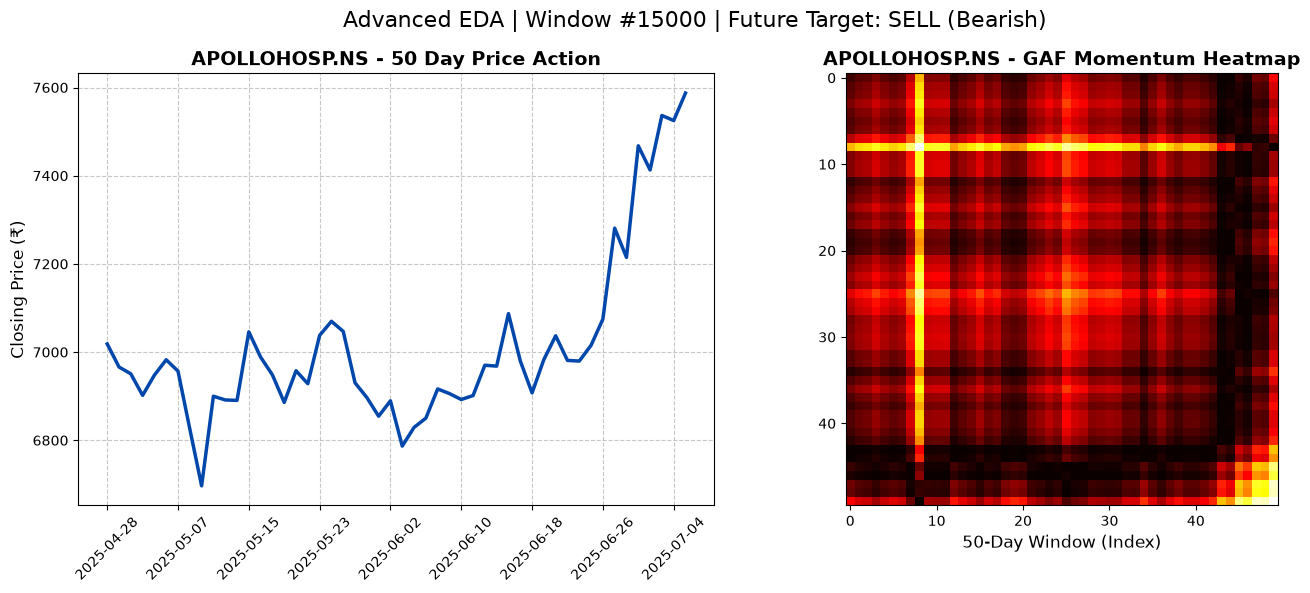

In [40]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

window_idx = 15000

stock_id, start_day = dataset.valid_indices[window_idx]
stock_df = dataset.stock_tables[stock_id]
end_day = start_day + dataset.window_size

ticker_name = stock_df['Ticker'].iloc[0]
real_dates = stock_df['Date'].values[start_day : end_day]
raw_prices = stock_df['Close'].values[start_day : end_day]

image, numbers, label = dataset[window_idx]
gaf_image = image.squeeze(0).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(real_dates, raw_prices, color='#0047AB', linewidth=2.5)
axes[0].set_title(f"{ticker_name} - 50 Day Price Action", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Closing Price (₹)", fontsize=12)

axes[0].tick_params(axis='x', rotation=45) 
axes[0].xaxis.set_major_locator(plt.MaxNLocator(10)) 
axes[0].grid(True, linestyle='--', alpha=0.7)

axes[1].imshow(gaf_image, cmap='hot')
axes[1].set_title(f"{ticker_name} - GAF Momentum Heatmap", fontsize=14, fontweight='bold')
axes[1].set_xlabel("50-Day Window (Index)", fontsize=12)

label_map = {0: "SELL (Bearish)", 1: "HOLD (Neutral)", 2: "BUY (Bullish)"}
target_text = label_map[label.item()]

plt.suptitle(f"Advanced EDA | Window #{window_idx} | Future Target: {target_text}", fontsize=16)
plt.tight_layout()
plt.show()

GAF is a mathematical way to convert 1D time series (1D line) into 2D spatial image without losing the element of time 

We can also feed the line chart or candlestick chart to the CNN but in those images the actual line is only 4-5% of the image and rest all image is irrelavent background that has nothing to do with the future price 

hence we use GAF image as it is a heatmap ( here representing 50 days data )

In [41]:
# Transferi Learning Using EfficientNet B0

Frezing the early layers while keep the advanced convolutional layers unfreezed

In [ ]:
""" 
import torch.nn as nn
import torchvision.models as models

class EfficientVisionBrain(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Loadibg EfficientNEt 
        self.effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        
        # Adjusting for grey scale image 
        original_conv = self.effnet.features[0][0]
        self.effnet.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)
        
        with torch.no_grad():
            self.effnet.features[0][0].weight = nn.Parameter(original_conv.weight.sum(dim=1, keepdim=True))
            
        for param in self.effnet.features.parameters():
            param.requires_grad = False
        for param in self.effnet.features[7].parameters():
            param.requires_grad = True
            
        num_features = self.effnet.classifier[1].in_features
        self.effnet.classifier[1] = nn.Linear(num_features, 64)

    def forward(self, image_tensor):
        vision_summary = self.effnet(image_tensor)
        return vision_summary

print("EfficientNet-B0 is loaded!") 

"""

In [118]:
# Using Restnet18 with all layers unfreezed for maximum optimization

In [120]:
import torch.nn as nn
import torchvision.models as models

class ResNetVisionBrain(nn.Module):
    def __init__(self):
        super().__init__()
        

        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        original_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(original_conv.weight.sum(dim=1, keepdim=True))
            
        for param in self.resnet.parameters():
            param.requires_grad = True
            
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_features, 64)

    def forward(self, image_tensor):
        vision_summary = self.resnet(image_tensor)
        return vision_summary

print("ResNet-18 is loaded")

ResNet-18 is loaded


In [121]:
# MLP architecture for the numerical value ( RSI and Volume )

In [122]:
class LogicBrain(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(100, 128), 
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )

    def forward(self, tabular_tensor):
        x = self.network(tabular_tensor)
        return x

print("Rsi and Vol MLP/ANN")

Rsi and Vol MLP/ANN


In [123]:
# Combining these 2 ( Vision + Numerical (RSI AND VOL ))

In [124]:
class FusionHead(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 64 (Vision) + 64 (Logic) = 128 combined
        self.network = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 3)  
        )

    def forward(self, vision_summary, logic_summary):
        combined_features = torch.cat((vision_summary, logic_summary), dim=1) 
        
        final_prediction = self.network(combined_features)
        
        return final_prediction

### Final Quant Model 

In [134]:
class MultiModalQuantModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.vision_brain = ResNetVisionBrain()
        self.logic_brain = LogicBrain()
        self.fusion_head = FusionHead()

    def forward(self, image_tensor, tabular_tensor):
        vision_summary = self.vision_brain(image_tensor)
        logic_summary = self.logic_brain(tabular_tensor)
        
        final_output = self.fusion_head(vision_summary, logic_summary)
        
        return final_output

### Using Purge Gap to do the Train test split and cross validation without data leakage 

In [135]:
from torch.utils.data import Subset, DataLoader

train_indices = []
test_indices = []
current_idx = 0

for stock_id, stock_data in enumerate(dataset.stock_tables):
    safe_days = len(stock_data) - dataset.window_size - dataset.forecast
    
    split_point = int(safe_days * 0.8)
    
    for day in range(safe_days):
        if day < split_point:
            train_indices.append(current_idx)
            
        elif day >= (split_point + dataset.window_size):
            test_indices.append(current_idx)
            
        current_idx += 1

train_dataset = Subset(dataset, train_indices)
test_dataset = Subset(dataset, test_indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training Windows: {len(train_dataset)}")
print(f"Testing Windows: {len(test_dataset)}")

Training Windows: 186718
Testing Windows: 36631


Purge Gap deletes the overlapping data from train and the test data

In [136]:
## Optimizer and Scheldule

In [137]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

vision_params = quant_machine.vision_brain.parameters()
logic_params = quant_machine.logic_brain.parameters()
fusion_params = quant_machine.fusion_head.parameters()

optimizer = optim.AdamW([
    {'params': vision_params, 'lr': 1e-5},
    {'params': logic_params, 'lr': 1e-3},
    {'params': fusion_params, 'lr': 1e-3}
], weight_decay=1e-4)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [138]:
# Class Weight Adjustment - Fixing Imbalance 

In [139]:
all_train_labels = [label for _, _, label in train_dataset]
class_counts = np.bincount(all_train_labels)

print(f"Total Sells Signal (0): {class_counts[0]}") 
print(f"Total Holds signal (1): {class_counts[1]}")
print(f"Total Buys signal (2): {class_counts[2]}")

total_samples = sum(class_counts)
weights = [total_samples / class_counts[0], 
           total_samples / class_counts[1], 
           total_samples / class_counts[2]]

min_weight = min(weights)
normalized_weights = [w / min_weight for w in weights]

class_weights_tensor = torch.tensor(normalized_weights, dtype=torch.float32).to(device)

Total Sells Signal (0): 50502
Total Holds signal (1): 76476
Total Buys signal (2): 59740


In [140]:
### Focal Loss Cross Entropy

In [141]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(log_probs)
        
        targets_view = targets.view(-1, 1)
        pt = probs.gather(1, targets_view).squeeze(1)
        log_pt = log_probs.gather(1, targets_view).squeeze(1)
        
        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            log_pt = log_pt * at
            
        focal_loss = -1 * ((1 - pt) ** self.gamma) * log_pt
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0).to(device)

In [142]:
# harware setup 

In [143]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device - {device.type.upper()}")

Device - CUDA


In [144]:
quant_machine = MultiModalQuantModel().to(device)
epochs = 2
best_val_loss = float('inf')

for epoch in range(epochs):
    quant_machine.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, tabulars, labels in train_loader:
        images, tabulars, labels = images.to(device), tabulars.to(device), labels.to(device)
        
        optimizer.zero_grad()
    
        predictions = quant_machine(images, tabulars)
        loss = criterion(predictions, labels)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        _, predicted = torch.max(predictions, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train

    quant_machine.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, tabulars, labels in test_loader:
            images, tabulars, labels = images.to(device), tabulars.to(device), labels.to(device)
            
            predictions = quant_machine(images, tabulars)
            loss = criterion(predictions, labels)
            
            running_val_loss += loss.item()
            _, predicted = torch.max(predictions, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(test_loader)
    epoch_val_acc = 100 * correct_val / total_val

    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {epoch_train_loss:.4f} and Accuracy: {epoch_train_acc:.2f}%")
    print(f"Validation Loss: {epoch_val_loss:.4f} and Accuracy: {epoch_val_acc:.2f}%")
    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        
        torch.save(quant_machine.state_dict(), "quant_master_weights.pth")
        print(f"New High score model saved to disk (test Loss: {best_val_loss:.4f})")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\mishr/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Epoch [1/2]
Train Loss: 0.6287 and Accuracy: 32.97%
Validation Loss: 0.6113 and Accuracy: 30.12%
New High score model saved to disk (test Loss: 0.6113)
Epoch [2/2]
Train Loss: 0.6279 and Accuracy: 33.22%
Validation Loss: 0.6103 and Accuracy: 30.17%
New High score model saved to disk (test Loss: 0.6103)
